<a href="https://colab.research.google.com/github/arathipkb/Early_disease_prediction/blob/main/early_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("Training.csv")
df.head()

,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,...,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin,prognosis
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AIDS
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AIDS
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AIDS
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AIDS
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AIDS


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Healthcare.csv to Healthcare (4).csv
Saving Symptom-severity.csv to Symptom-severity (4).csv
Saving dataset.csv to dataset (4).csv
Saving Training.csv to Training (4).csv
Saving Testing.csv to Testing (6).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("dataset.csv")
df.head()

,Disease,Symptom_0,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16
0,AIDS,muscle_wasting,patches_in_throat,high_fever,extra_marital_contacts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AIDS,patches_in_throat,high_fever,extra_marital_contacts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AIDS,muscle_wasting,high_fever,extra_marital_contacts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AIDS,muscle_wasting,patches_in_throat,extra_marital_contacts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AIDS,muscle_wasting,patches_in_throat,high_fever,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     313 non-null    object
 1   Symptom_0   313 non-null    object
 2   Symptom_1   313 non-null    object
 3   Symptom_2   313 non-null    object
 4   Symptom_3   281 non-null    object
 5   Symptom_4   234 non-null    object
 6   Symptom_5   186 non-null    object
 7   Symptom_6   158 non-null    object
 8   Symptom_7   140 non-null    object
 9   Symptom_8   120 non-null    object
 10  Symptom_9   110 non-null    object
 11  Symptom_10  68 non-null     object
 12  Symptom_11  47 non-null     object
 13  Symptom_12  30 non-null     object
 14  Symptom_13  19 non-null     object
 15  Symptom_14  18 non-null     object
 16  Symptom_15  10 non-null     object
 17  Symptom_16  1 non-null      object
dtypes: object(18)
memory usage: 44.1+ KB


,Disease,Symptom_0,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16
count,313,313,313,313,281,234,186,158,140,120,110,68,47,30,19,18,10,1
unique,42,38,51,56,54,38,32,26,21,22,21,18,11,8,4,3,3,1
top,Chicken pox,vomiting,vomiting,fatigue,high_fever,headache,nausea,abdominal_pain,loss_of_appetite,malaise,yellowing_of_eyes,sinus_pressure,malaise,congestion,chest_pain,loss_of_smell,muscle_pain,muscle_pain
freq,10,46,56,46,30,24,21,22,16,17,11,8,11,8,16,8,8,1


In [ ]:
df.isnull().sum()

,0
Disease,0
Symptom_0,0
Symptom_1,0
Symptom_2,0
Symptom_3,32
Symptom_4,79
Symptom_5,127
Symptom_6,155
Symptom_7,173
Symptom_8,193


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)


In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print("actual columns in df:",df.columns.tolist())
df.columns = df.columns.str.strip()
symptom_columns = [col for col in df.columns if col.startswith('Symptom_')]
for col in symptom_columns:
    df[col] = df[col].str.lower()

actual columns in df: ['Disease', 'Symptom_0', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16']


In [ ]:
import re
symptom_columns = [col for col in df.columns if col.startswith('Symptom_')]
for col in symptom_columns:
    df[col] = df[col].apply(lambda x: re.sub('[^a-zA-Z ]','', str(x)))

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Disease'] = le.fit_transform(df['Disease'])

<Axes: >

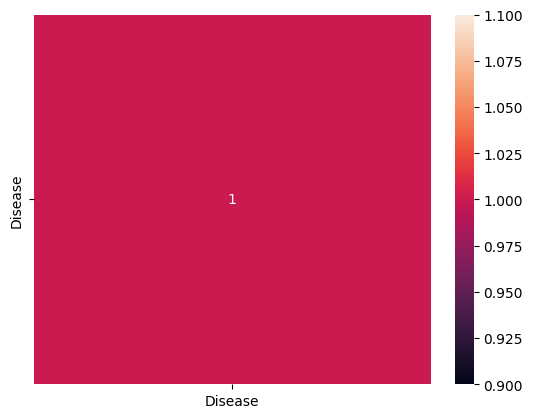

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [ ]:
numerical_df = df.select_dtypes(include=['number'])
Q1 = numerical_df.quantile(0.25)
Q3 = numerical_df.quantile(0.75)

<Axes: >

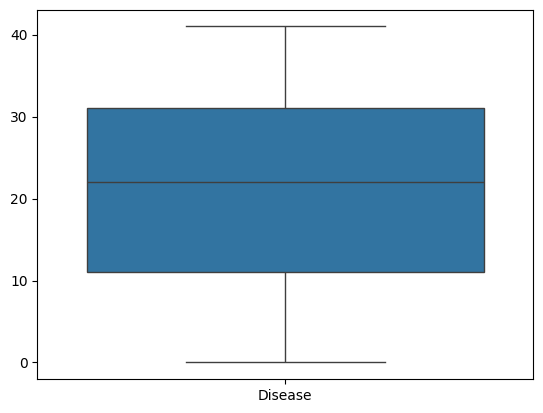

In [ ]:
sns.boxplot(data=df)

In [ ]:
X = df.drop('Disease', axis=1)
y = df['Disease']

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

X = df.drop("Disease", axis=1)
y = df["Disease"]

print("Total rows:", len(df))

if len(df) <= 1:
    print("Warning: DataFrame has 1 or fewer rows. Cannot perform a meaningful train-test split.")
    print("Assigning all data to training set and creating empty test sets to avoid error.")
    X_train, y_train = X, y
    X_test = pd.DataFrame(columns=X.columns)
    y_test = pd.Series(dtype=y.dtype)
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.5, random_state=42
    )

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Total rows: 313
X_train shape: (156, 17)
X_test shape: (157, 17)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Identify categorical columns for one-hot encoding (all Symptom_ columns)
symptom_columns = [col for col in X_train.columns if col.startswith('Symptom_')]

# Apply one-hot encoding to X_train and X_test
X_train_encoded = pd.get_dummies(X_train, columns=symptom_columns, prefix=symptom_columns)
X_test_encoded = pd.get_dummies(X_test, columns=symptom_columns, prefix=symptom_columns)

# Align columns - this is crucial to ensure both datasets have the same columns
# If a symptom appears in train but not test, or vice-versa, get_dummies will produce different columns.
# Reindex ensures both dataframes have the union of all columns, filling with 0 if a column is missing.
all_columns = list(set(X_train_encoded.columns) | set(X_test_encoded.columns))
X_train_encoded = X_train_encoded.reindex(columns=all_columns, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=all_columns, fill_value=0)

model = RandomForestClassifier(random_state=42)

model.fit(X_train_encoded, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test_encoded)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8343949044585988
              precision    recall  f1-score   support

           0       0.40      1.00      0.57         2
           1       0.80      1.00      0.89         4
           2       0.80      1.00      0.89         4
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         4
           9       0.83      1.00      0.91         5
          10       0.75      0.43      0.55         7
          11       0.83      1.00      0.91         5
          12       1.00      1.00      1.00         4
          13       1.00      1.00      1.00         2
          14       0.67      1.00      0.80         2
          15       1.00      0.50      0.67         4
          16       0.00      0.00      0.00         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


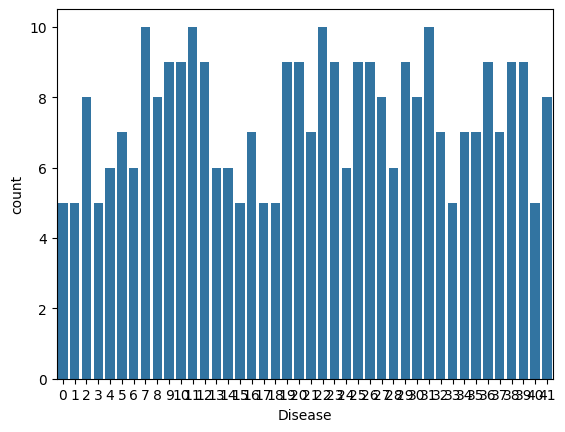

In [ ]:
sns.countplot(x=y)
plt.show()

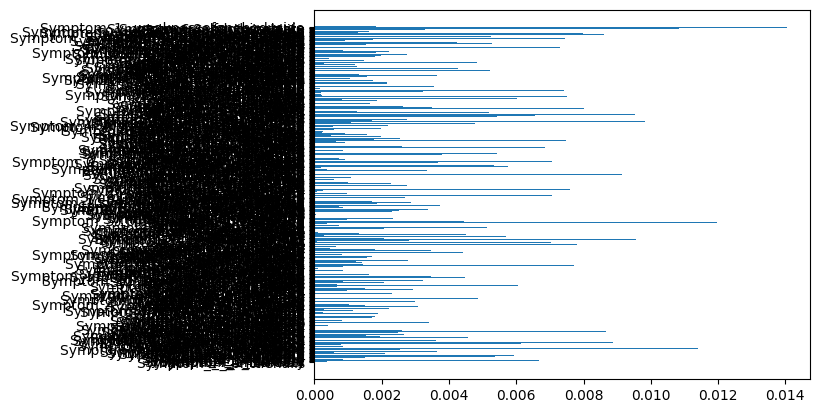

In [ ]:
importance = model.feature_importances_

plt.barh(X_train_encoded.columns, importance)
plt.show()

In [ ]:
import pandas as pd
import re

# Define the symptom columns, which are available from the notebook state
symptom_columns = ['Symptom_0', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16']

# Create a sample DataFrame with symptoms for prediction.
# Replace the symptom strings below with the actual symptoms you want to predict.
# Use 'nan' for symptoms that are not present in the sample.
# Example uses symptoms from the first row of the original dataset:
new_sample_data = pd.DataFrame([[
    'musclewasting', 'patchesinthroat', 'highfever', 'extramaritalcontacts',
    'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan'
]], columns=symptom_columns)

# Apply cleaning steps similar to how the training data was processed
for col in symptom_columns:
    # Ensure value is string before calling .lower()
    new_sample_data[col] = new_sample_data[col].astype(str).str.lower()
    new_sample_data[col] = new_sample_data[col].apply(lambda x: re.sub('[^a-zA-Z ]','', str(x)))

# One-hot encode the new sample data
sample_encoded = pd.get_dummies(new_sample_data, columns=symptom_columns, prefix=symptom_columns)

# Align the columns of the encoded sample with the columns the model was trained on.
# `all_columns` variable is available from the kernel state after model training.
sample_encoded = sample_encoded.reindex(columns=all_columns, fill_value=0)

# Now make the prediction
prediction = model.predict(sample_encoded)

# Decode the predicted disease label back to its original string representation if `le` is available.
# Assuming `le` (LabelEncoder) was used and is still available in the kernel state.
# If `le` is not available, you would need to reconstruct it or map manually.
if 'le' in globals(): # Check if label encoder is available
    predicted_disease_name = le.inverse_transform(prediction)
    print("Predicted Disease:", predicted_disease_name[0])
else:
    print("Predicted Disease (encoded label):", prediction[0])

Predicted Disease: 9


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier